In [1]:
%pwd

'e:\\Health_Care_Assistant_ChatBot-End-to-End-RAG-Implementaion\\research'

In [2]:
import os
os.chdir("../")

# Testing Logger and Exception Handling Modules

This notebook tests the `logger.py` and `exception_handling.py` modules in the `utils` folder.

In [1]:
# Test Logger Module
import sys
sys.path.append('..')  # Add parent directory to path to import utils

from utils.logger import setup_logging
import logging

# Setup logging
setup_logging(log_level="DEBUG", log_dir="../logs")

# Get logger
logger = logging.getLogger(__name__)

# Test logging at different levels
logger.debug("This is a debug message")
logger.info("This is an info message")
logger.warning("This is a warning message")
logger.error("This is an error message")

print("Logger test completed. Check console output and ../logs/app.log for messages.")

[2026-04-27 21:57:06] [DEBUG] [__main__] This is a debug message
[2026-04-27 21:57:06] [INFO] [__main__] This is an info message
[2026-04-27 21:57:06] [WARNING] [__main__] This is a warning message
[2026-04-27 21:57:06] [ERROR] [__main__] This is an error message
Logger test completed. Check console output and ../logs/app.log for messages.


In [2]:
# Test Exception Handling Module
from utils.exception_handling import PipelineException

# Test creating a PipelineException without original exception
try:
    raise ValueError("Test error")
except ValueError as e:
    pipeline_exc = PipelineException("An error occurred during processing", original_exception=e, context={"step": "data_loading", "file": "test.csv"})
    print("PipelineException created successfully:")
    print(f"Message: {pipeline_exc}")
    print(f"Full Trace:\n{pipeline_exc.full_trace()}")

# Test creating a PipelineException with context
simple_exc = PipelineException("Simple error message", context={"user_id": 123, "action": "login"})
print("\nSimple PipelineException:")
print(f"Message: {simple_exc}")

print("Exception handling test completed.")

PipelineException created successfully:
Message: 4203184583.py:6 | An error occurred during processing | caused_by=ValueError | original=ValueError('Test error') | context={ step='data_loading', file='test.csv' }
Full Trace:
Traceback (most recent call last):
  File "C:\Users\shree\AppData\Local\Temp\ipykernel_19364\4203184583.py", line 6, in <module>
    raise ValueError("Test error")
ValueError: Test error


Simple PipelineException:
Message: exception_handling.py:25 | Simple error message | context={ user_id=123, action='login' }
Exception handling test completed.


In [2]:
!ollama list


NAME                        ID              SIZE      MODIFIED    
nomic-embed-text:latest     0a109f422b47    274 MB    5 weeks ago    
llama3.1:latest             46e0c10c039e    4.9 GB    7 weeks ago    
embeddinggemma:latest       85462619ee72    621 MB    7 weeks ago    
mxbai-embed-large:latest    468836162de7    669 MB    7 weeks ago    


In [ ]:
!ollama

# Testing Chunk size and overlap hyperparameter

In [3]:
from utils.helper_function import display_chunks, visualize_chunk_sizes, compare_chunkers

Helper functions loaded!


In [18]:
## Loading the data
file_path = "Data\Output\medical_data.md"

with open(file_path, "r" , encoding='utf-8') as f:
    doc = f.read()



<>:2: SyntaxWarning: invalid escape sequence '\O'
<>:2: SyntaxWarning: invalid escape sequence '\O'
C:\Users\shree\AppData\Local\Temp\ipykernel_7744\1891535653.py:2: SyntaxWarning: invalid escape sequence '\O'
  file_path = "Data\Output\medical_data.md"


In [19]:
len(doc)

10384246


Total chunks: 6834

Chunk 1:
Text: 

# --- Source: Davidson's Principles & Practice of Medicine-pages-1.md ---

<!-- image -->

In this image we can see a collage of different images.<end_of_utteranc

<!-- image -->

<!-- image -->

<!...
Token count: 820
--------------------------------------------------------------------------------

Chunk 2:
Text: 

Place Peel Off Sticker Here

In the foreground of a photograph, there is text that reads "Davidson's Principles and Practice of Medicine".<end_of_utteranc

<!-- image -->

In this image I can see a ...
Token count: 820
--------------------------------------------------------------------------------

Chunk 3:
Text:  boxes in Chapter 8 © Julian White.

No part of this publication may be reproduced or transmitted in any form or by any means, electronic or mechanical, including photocopying, recording, or any infor...
Token count: 820
--------------------------------------------------------------------------------

... and 6831 more chunks


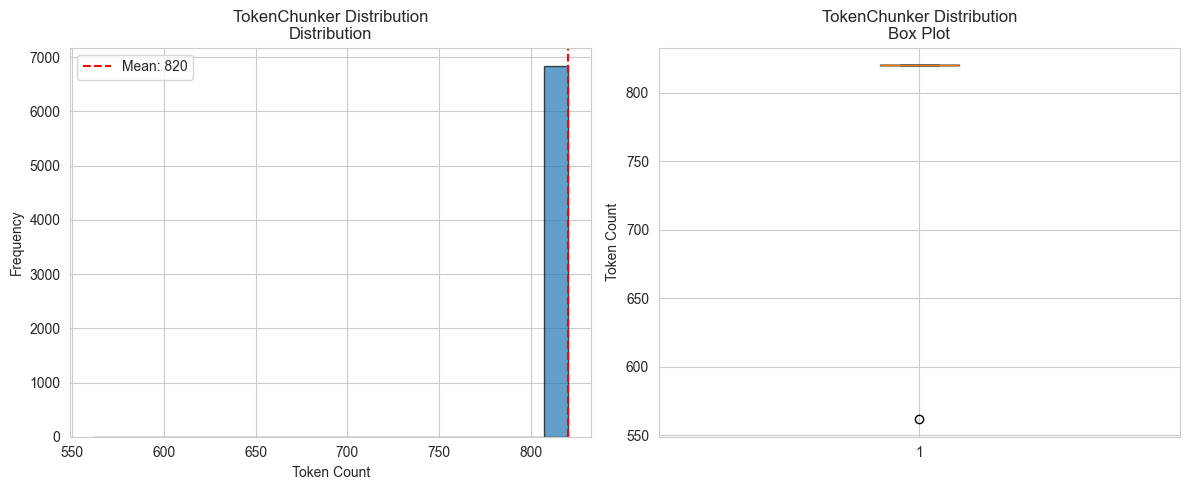


Statistics:
  Mean: 820.0
  Median: 820.0
  Std Dev: 3.1
  Min: 562
  Max: 820


In [23]:
from chonkie import TokenChunker
from tokenizers import Tokenizer

# Initialize tokenizer
tokenizer = Tokenizer.from_pretrained("gpt2")

# Create TokenChunker
token_chunker = TokenChunker(
    tokenizer=tokenizer,
    chunk_size=820,      # Max tokens per chunk
    chunk_overlap=128    # Overlapping tokens between chunks
)

# Chunk technical document ation
token_chunks = token_chunker.chunk(doc)


# Display results
display_chunks(token_chunks)
visualize_chunk_sizes(token_chunks, "TokenChunker Distribution")


Total chunks: 6224

Chunk 1:
Text: 

# --- Source: Davidson's Principles & Practice of Medicine-pages-1.md ---

<!-- image -->

In this image we can see a collage of different images.<end_of_utteranc

<!-- image -->

<!-- image -->

<!...
Token count: 803
--------------------------------------------------------------------------------

Chunk 2:
Text: Stanley Davidson was born in Sri Lanka and began his medical undergraduate training at Trinity College, Cambridge; this was interrupted by World War I and later resumed in Edinburgh. He was seriously ...
Token count: 807
--------------------------------------------------------------------------------

Chunk 3:
Text: 
Eighteenth edition 1999 Nineteenth edition 2002 Twentieth edition 2006 Twenty-first edition 2010 Twenty-second edition 2014

Twenty-third edition 2018

Twenty-third edition 2022

ISBN 978-0-7020-7028...
Token count: 799
--------------------------------------------------------------------------------

... and 6221 more chunks


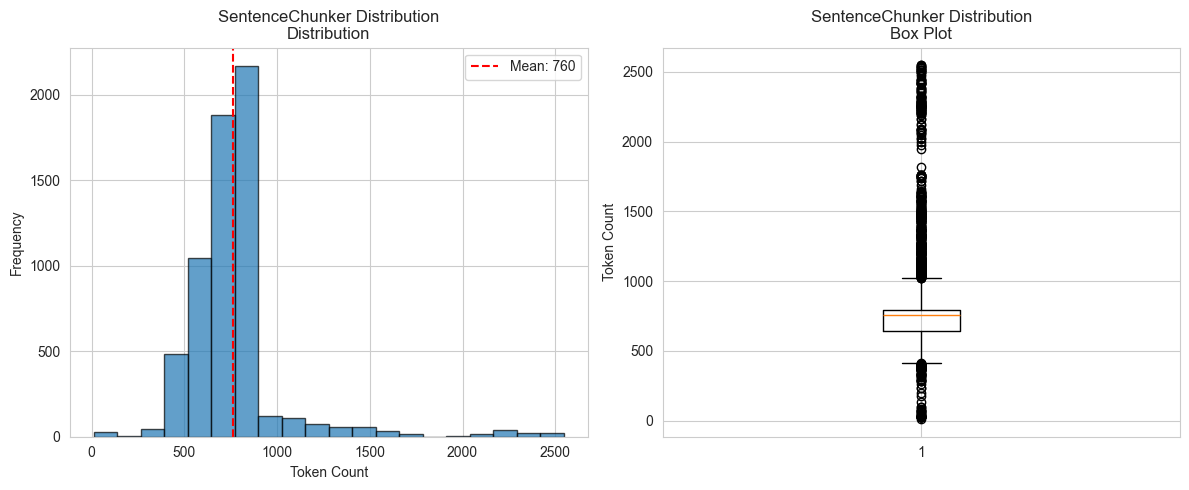


Statistics:
  Mean: 760.0
  Median: 757.0
  Std Dev: 273.6
  Min: 12
  Max: 2547


In [24]:
from chonkie import SentenceChunker

# Create SentenceChunker
sentence_chunker = SentenceChunker(
    tokenizer=tokenizer,
    chunk_size=820,
    min_sentences_per_chunk=1  # Ensure at least 2 sentences per chunk
)

# Chunk research paper
sentence_chunks = sentence_chunker.chunk(doc)

display_chunks(sentence_chunks)
visualize_chunk_sizes(sentence_chunks, "SentenceChunker Distribution")


Total chunks: 7189

Chunk 1:
Text: 

# --- Source: Davidson's Principles & Practice of Medicine-pages-1.md ---

<!-- image -->

In this image we can see a collage of different images.<end_of_utteranc

<!-- image -->

<!-- image -->

<!...
Token count: 779
--------------------------------------------------------------------------------

Chunk 2:
Text: 
This famous textbook was the brainchild of one of the great Professors of Medicine of the 20th century. Stanley Davidson was born in Sri Lanka and began his medical undergraduate training at Trinity ...
Token count: 795
--------------------------------------------------------------------------------

Chunk 3:
Text: 
Eleventh edition 1974 Twelfth edition 1977 Thirteenth edition 1981 Fourteenth edition 1984 Fifteenth edition 1987 Sixteenth edition 1991

Seventeenth edition 1995

Eighteenth edition 1999 Nineteenth ...
Token count: 720
--------------------------------------------------------------------------------

... and 7186 more chunks


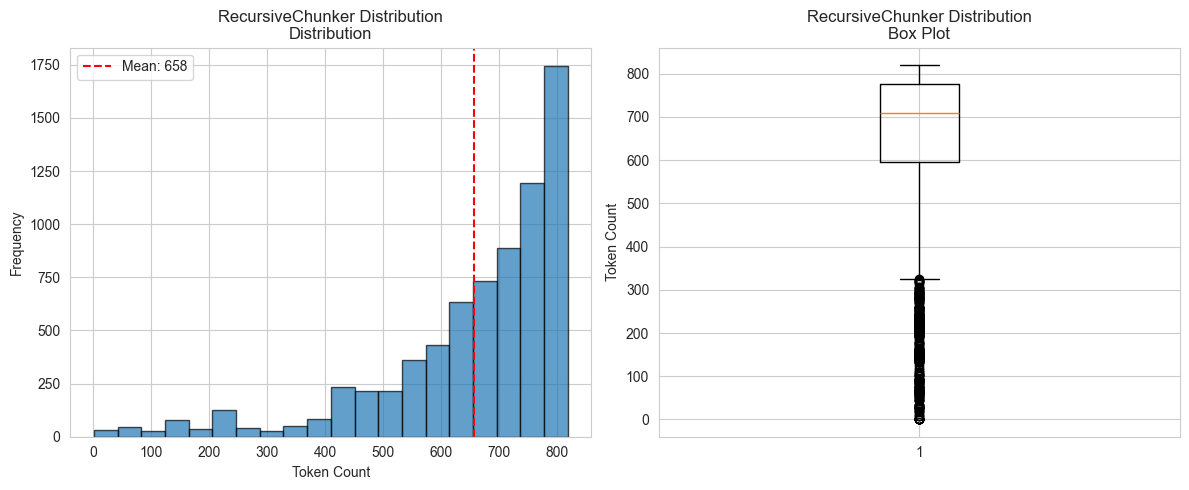


Statistics:
  Mean: 657.8
  Median: 708.0
  Std Dev: 162.9
  Min: 1
  Max: 819


In [25]:
from chonkie import RecursiveChunker

# Create RecursiveChunker
recursive_chunker = RecursiveChunker(
    tokenizer=tokenizer,
    chunk_size=820
)

# Chunk technical documentation (has good structure)
recursive_chunks = recursive_chunker(doc)  # Can also use __call__

display_chunks(recursive_chunks)
visualize_chunk_sizes(recursive_chunks, "RecursiveChunker Distribution")

In [ ]:
from chonkie import SentenceTransformerEmbeddings


In [11]:
! ollama list

NAME                        ID              SIZE      MODIFIED     
qwen3-vl:latest             901cae732162    6.1 GB    5 days ago      
nomic-embed-text:latest     0a109f422b47    274 MB    6 weeks ago     
llama3.1:latest             46e0c10c039e    4.9 GB    8 weeks ago     
embeddinggemma:latest       85462619ee72    621 MB    8 weeks ago     
mxbai-embed-large:latest    468836162de7    669 MB    2 months ago    


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7558.49it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
e:\Health_Care_Assistant_ChatBot-End-to-End-RAG-Implementaion\medibot\Lib\site-packages\chonkie\embeddings\sentence_transformer.py:57: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self._dimension = self.model.get_sentence_embedding_dimension()
Token indices sequence length is longer than the specified maximum sequence length for this model (912 > 256). Running this sequence through the model will result in indexing errors



Total chunks: 21326

Chunk 1:
Text: 

# --- Source: Davidson's Principles & Practice of Medicine-pages-1.md ---

<!-- image -->

In this image we can see a collage of different images.<end_of_utteranc

<!-- image -->

<!-- image -->
...
Token count: 68
--------------------------------------------------------------------------------

Chunk 2:
Text: 
<!-- image -->

<!-- image -->

## $Q\VFUHHQ
$WL \
$Q\WLPH
$K \
$Q\ZKHUH

$FWLYDWHWKHH%RRNYHUVLRQ RIWKLVWLWOHDWQRDGGLWLRQDOFKDUJH

6WXGHQW&amp;RQVXOWH%RRNVJLYH\RXWKHSRZHUW...
Token count: 362
--------------------------------------------------------------------------------

Chunk 3:
Text: 
In the foreground of a photograph, there is text that reads "Davidson's Principles and Practice of Medicine".<end_of_utteranc

<!-- image -->

In this image I can see a man in the black and white col...
Token count: 133
--------------------------------------------------------------------------------

... and 21323 more chunks


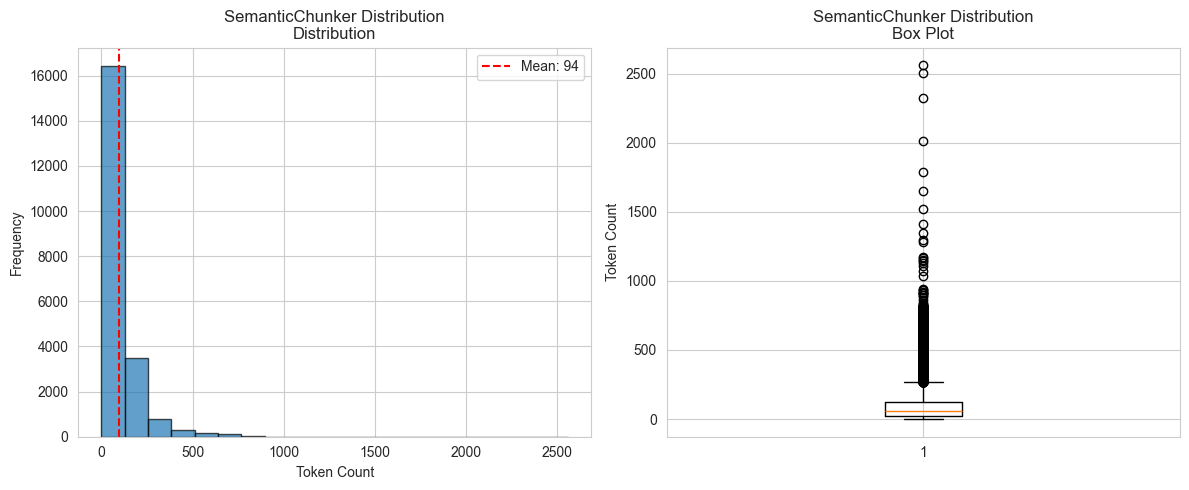


Statistics:
  Mean: 94.1
  Median: 58.0
  Std Dev: 119.1
  Min: 0
  Max: 2559


In [26]:
from chonkie import SemanticChunker

semantic_chunker = SemanticChunker(
    embedding_model= "sentence-transformers/all-MiniLM-L6-v2",
    thershold = 0.8,
    chunk_size= 820,
    min_sentences = 3
)


# Chunk research paper (has multiple topics)
semantic_chunks = semantic_chunker.chunk(doc)

display_chunks(semantic_chunks)
visualize_chunk_sizes(semantic_chunks, "SemanticChunker Distribution")